# Last-Round CPA — MSPM0L2228 AES-ADV (hardware AES-128) with Husky

Recover the AES-128 key from the **MSPM0L2228 AES-ADV hardware accelerator** by
correlation power analysis, using the `mspm0l2228_aes_trigger.c` victim firmware
(secret key compiled in, never sent).

**This is a hardware-AES attack — different and harder than software AES:**
- Leakage model is the **Hamming distance of the last round**, not the S-box
  output HW. We recover the **round-10 key** `K10`, then invert the AES-128 key
  schedule to the master key.
- The MSPM0 free-runs on its own clock, so capture is **asynchronous**: the ADC
  samples on the Husky's internal clock, not phase-locked to the target. Expect
  jitter, so **alignment** (section 6) is usually needed and **trace counts are
  high** (tens of thousands+).
- A wide/fast HW core may leak weakly; if `K10` doesn't converge, the model
  variant, alignment, and trace count are the levers (section 9).

The analysis pipeline (last-round CPA + key-schedule inversion) is verified on
synthetic Hamming-distance leakage; the real traces test whether the AES-ADV
core matches this model.


## 1. Parameters

In [1]:
SAMPLES   = 2000        # focused window: covers the core burst (~650) + readout (~1000)
N_TRACES  = 100000      # wide HW AES needs lots; this is the main lever. Lower if RAM/time tight
BAUD      = 115200      # MUST match the firmware UART

# ADC sampling (asynchronous: Husky's own clock, target is NOT driven by Husky)
CLKGEN    = 20e6
ADC_MUL   = 10          # sample rate = CLKGEN * ADC_MUL (20e6*10 = 200 MS/s max)

# OPTIONAL check only — the key you compiled into SECRET_KEY[]. None = blind.
KNOWN_KEY = bytes.fromhex('2b7e151628aed2a6abf7158809cf4f3c')   # or None
#2f77fe8b824806852bc3876c51ad9f94

## 2. Connect the Husky for asynchronous capture

The MSPM0 is powered and clocked by your own board; the Husky only measures
power (shunt on the MSPM0 core supply), talks UART on tio1/tio2, and triggers on
tio4. Re-run this cell to recover from a wedged/fast-read state.

In [2]:
import chipwhisperer as cw
import time

def connect():
    global scope, target
    try: scope.dis()
    except Exception: pass
    scope = cw.scope()
    scope.default_setup()

    scope.clock.clkgen_freq = CLKGEN
    scope.clock.adc_mul     = ADC_MUL       # ADC runs on Husky's internal clock
    scope.adc.samples       = SAMPLES
    scope.adc.offset        = 0
    scope.adc.basic_mode    = 'rising_edge'
    scope.trigger.triggers  = 'tio4'        # GPIO_TRIG from the MSPM0
    # Gain: tune so §5b 'ADC range used' is ~0.3-0.5 WITHOUT clipping (check §4 plot
    # isn't flat-topped). ~2 was too small (0.15), ~25 clipped — 10 is a start.
    scope.gain.mode = 'high'; scope.gain.db = 10
    scope.io.tio1 = 'serial_rx'
    scope.io.tio2 = 'serial_tx'
    scope.io.hs2  = None                    # do NOT drive the target clock

    target = cw.target(scope, cw.targets.SimpleSerial)   # used only for raw UART
    target.baud = BAUD
    time.sleep(0.3)
    return scope, target

scope, target = connect()
print('FW', scope.fw_version, '| adc_mul', scope.clock.adc_mul, '| gain.db', scope.gain.db)

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 137209                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.clock.adc_rate                     changed from 0.0                       to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2       

In [3]:
scope.errors

sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = False
extclk error    = False
trace errors    = False

In [ ]:
scope.errors.clear()

## 3. Raw UART link + one-shot capture

`mspm0l2228_aes_trigger.c` speaks a raw protocol (`'p'`+16 bytes → `'r'`+16
bytes), so we drive the serial line directly rather than via SimpleSerial.

**Wiring (verified firmware labels):** MSPM0 `UART0` is **PA10 = TX**, **PA11 =
RX** at **115200 8N1**; the trigger `GPIO_TRIG` is **PA0** (package pin 1), idle
low. Connect **PA10 → Husky tio1** (scope `serial_rx`), **Husky tio2 → PA11**
(scope `serial_tx`), **PA0 → Husky tio4**, and a common **GND**. The Husky does
**not** drive the MSPM0 clock (async capture).

In [4]:
import numpy as np

def _to_bytes(s):
    return bytes(bytearray(map(ord, s))) if isinstance(s, str) else bytes(s)

def capture_one(pt16, timeout=200):
    target.flush()
    scope.arm()
    target.write(b'p' + bytes(pt16))
    if scope.capture():                 # True == timeout (no trigger)
        return None, None
    wave = scope.get_last_trace()
    resp = _to_bytes(target.read(17, timeout=timeout))
    if len(resp) < 17 or resp[0:1] != b'r':
        return wave, None               # trace captured but framing off
    return wave, resp[1:17]             # (wave, ciphertext)

## 4. Sanity check: one trace

Confirm the link and that the trigger window holds the AES burst. Retune `scope.gain.db` if the trace is clipped (flat) or tiny.

ciphertext: e8ead77e1d3fa09eb9426d69d6cd4f58


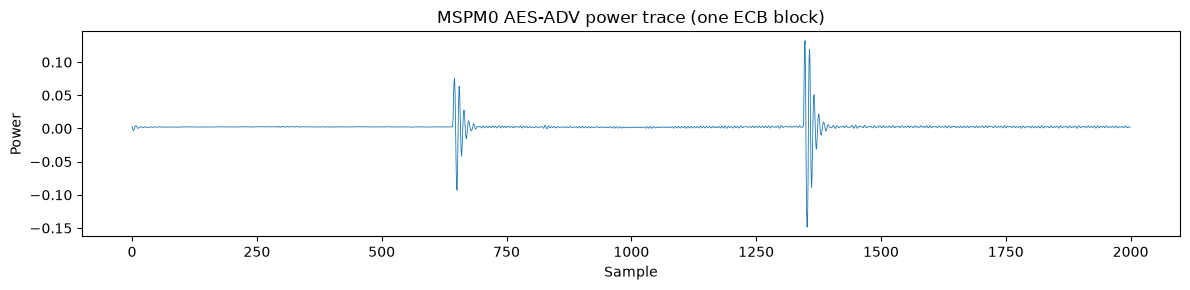

In [5]:
import matplotlib.pyplot as plt

rng = np.random.default_rng()
pt = rng.integers(0, 256, 16, dtype=np.uint8)
wave, ct = capture_one(pt)
assert wave is not None, 'No trigger — check GPIO_TRIG -> tio4 wiring and firmware.'
print('ciphertext:', ct.hex() if ct else 'NO/!=r framing — check BAUD and protocol')

plt.figure(figsize=(12,3))
plt.plot(wave, linewidth=0.6)
plt.title('MSPM0 AES-ADV power trace (one ECB block)')
plt.xlabel('Sample'); plt.ylabel('Power'); plt.tight_layout(); plt.show()

In [6]:
# Optional: UART link test ONLY (no scope / no trigger needed).
# Verifies the 'p' -> 'r' protocol independently of the GPIO_TRIG wiring, so you
# can tell a serial problem apart from a trigger problem.
import time
target.flush(); time.sleep(0.1); target.flush()      # clear any stale bytes

pt = bytes(16)                                        # all-zero plaintext
target.write(b'p' + pt)                               # raw bytes, matches firmware
time.sleep(0.05)
resp = _to_bytes(target.read(17, timeout=300))
if len(resp) == 17 and resp[0:1] == b'r':
    print('link OK   ciphertext:', resp[1:17].hex())
    # AES128-ECB(2b7e...4f3c, 0^16) == 7df76b0c1ab899b33e42f047b91b546f
else:
    print(f'link FAIL  got {len(resp)} byte(s):', resp.hex())
    print('  -> check BAUD=115200, PA10(TX)->tio1, tio2->PA11(RX), common GND')

link OK   ciphertext: 7df76b0c1ab899b33e42f047b91b546f


## 5. Capture the attack set

Random plaintexts; record the **ciphertext** per trace (the last-round attack needs ciphertexts). Saved to `mspm0_hwaes_traces.npz`.

In [7]:
from tqdm.notebook import trange

# Preallocated (memory-efficient for large N) + interruptible: Ctrl-C keeps what was
# captured, textouts is always saved, uncompressed savez is fast and Ctrl-C-safe.
traces   = np.empty((N_TRACES, SAMPLES), dtype=np.float32)
textouts = np.empty((N_TRACES, 16),      dtype=np.uint8)
n = bad = 0
try:
    for _ in trange(N_TRACES, desc='Capturing'):
        pt = rng.integers(0, 256, 16, dtype=np.uint8)
        w, ct = capture_one(pt)
        if w is None or ct is None:
            bad += 1; continue
        traces[n]   = w
        textouts[n] = np.frombuffer(ct, dtype=np.uint8)   # ct is bytes -> uint8 row
        n += 1
except KeyboardInterrupt:
    print(f'interrupted — keeping the {n} traces captured so far')

traces   = traces[:n]          # trim to what we actually kept
textouts = textouts[:n]
save = dict(traces=traces, textouts=textouts)
if KNOWN_KEY is not None:
    save['key'] = np.frombuffer(KNOWN_KEY, dtype=np.uint8)
np.savez('mspm0_hwaes_traces.npz', **save)
print(f'kept {n}, dropped {bad}; {traces.shape[1]} samples each; saved to npz '
      f'(~{traces.nbytes/1e6:.0f} MB in RAM)')

Capturing:   0%|          | 0/100000 [00:00<?, ?it/s]

kept 100000, dropped 0; 2000 samples each; saved to npz (~800 MB in RAM)


## 5b. Signal-quality gate — are we measuring the chip at all?

Before any attack, confirm MEASURE actually sees the MSPM0's current. Averaging
all traces cancels random noise, so a real capture leaves a clear AES **burst**;
a dead-flat averaged trace means the shunt / power path isn't carrying the chip's
current (turning up gain won't help). Fix that before running §6b / §7.

ADC range used       : 0.290 of ~1.0   (raise scope.gain.db if below ~0.2)
averaged-trace std   : 0.005308
expected noise floor : 0.000009
VERDICT: signal present — proceed


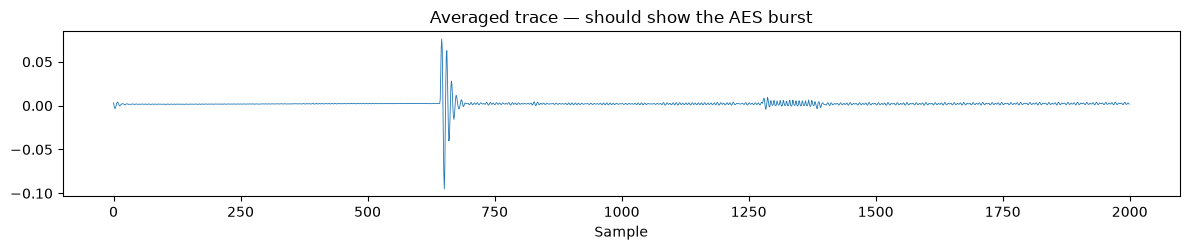

In [8]:
# 5b. Signal-quality gate — did we actually MEASURE the chip's current?
# A valid capture (a) fills a fair bit of the ADC range and (b) has a deterministic
# AES 'burst' that survives averaging. A flat averaged trace means the MEASURE input
# isn't seeing the chip (shunt / power-path problem) — no attack can work until fixed.
_rng   = float(traces.max() - traces.min())                 # vs ~1.0 full scale
_m     = traces.mean(0)                                     # averaged trace
_sig   = _m.std()
_noise = (traces.std(0) / np.sqrt(len(traces))).mean()      # expected noise in the mean
print(f'ADC range used       : {_rng:.3f} of ~1.0   (raise scope.gain.db if below ~0.2)')
print(f'averaged-trace std   : {_sig:.6f}')
print(f'expected noise floor : {_noise:.6f}')
print('VERDICT:', 'signal present — proceed' if _sig > 3*_noise else
      'NO CHIP SIGNAL — fix the shunt / power path, re-capture (do not attack yet)')
plt.figure(figsize=(12,2.6)); plt.plot(_m, lw=0.6)
plt.title('Averaged trace — should show the AES burst'); plt.xlabel('Sample')
plt.tight_layout(); plt.show()

In [ ]:
scope.errors.clear()

## 6. Align traces (asynchronous capture)

Because the target isn't phase-locked to the ADC, traces drift. This shifts each
trace to best-match a reference over a chosen window (coarse SAD alignment). If
the attack already works without it, skip; if `K10` is weak, this is the first
lever. Tune `REF_WIN` to a feature-rich part of the burst from the section-4
plot.

In [9]:
REF_WIN  = slice(200, 1200)   # a distinctive region of the AES burst
MAXSHIFT = 60                 # +/- samples to search

def align(traces, ref_win, maxshift):
    ref = traces[0, ref_win]
    ref = (ref - ref.mean()) / (ref.std() + 1e-9)
    out = np.zeros_like(traces)
    L = traces.shape[1]
    a, b = ref_win.start, ref_win.stop
    for i in range(traces.shape[0]):
        best, bs = -1e9, 0
        for sh in range(-maxshift, maxshift+1):
            seg = traces[i, a+sh:b+sh]
            if seg.shape[0] != (b-a): continue
            seg = (seg - seg.mean()) / (seg.std() + 1e-9)
            c = float(seg @ ref)
            if c > best: best, bs = c, sh
        out[i] = np.roll(traces[i], -bs)
    return out

# traces = align(traces, REF_WIN, MAXSHIFT)
# ^ left OFF: this burst is low-jitter so alignment didn't change the result, and the
#   Python loop is very slow at N=100k. Only enable (on a small subset) if §5b shows
#   the averaged burst smeared across many samples.
print('alignment ready (align() defined, not applied)')

alignment ready (align() defined, not applied)


## 6b. Leakage check with the known key (do this first)

Before brute-forcing all 256×16 guesses, use `KNOWN_KEY` to answer two questions
cheaply: **is there any first-order last-round leakage at all**, and **which
register model** this core leaks — the *same-byte* HD `HW(C_b ⊕ InvSbox(C_b ⊕ k))`
or the *ShiftRows-paired* HD `HW(C_sr[b] ⊕ InvSbox(C_b ⊕ k))`. Whichever shows a
peak well above the noise floor (~`4/√N`) is the model to attack with in §7. If
both sit at the floor, the attack cannot work yet — align (§6) and re-run; if
still flat, the core resists first-order CPA.

*(Your last run showed every byte at ≈`0.03` ≈ the `20000`-trace floor with the
same-byte model — i.e. no leakage found. This cell checks whether the ShiftRows
model leaks instead, which is the usual case for a hardware last round.)*

In [10]:
# Known-key diagnostic: which leakage model (if any) clears the noise floor?
assert KNOWN_KEY is not None, 'Set KNOWN_KEY in section 1 to run this check.'

# self-contained tables (so this runs before section 7 too)
SBOX = bytes.fromhex(
"637c777bf26b6fc53001672bfed7ab76ca82c97dfa5947f0add4a2af9ca472c0"
"b7fd9326363ff7cc34a5e5f171d8311504c723c31896059a071280e2eb27b275"
"09832c1a1b6e5aa0523bd6b329e32f8453d100ed20fcb15b6acbbe394a4c58cf"
"d0efaafb434d338545f9027f503c9fa851a3408f929d38f5bcb6da2110fff3d2"
"cd0c13ec5f974417c4a77e3d645d197360814fdc222a908846eeb814de5e0bdb"
"e0323a0a4906245cc2d3ac629195e479e7c8376d8dd54ea96c56f4ea657aae08"
"ba78252e1ca6b4c6e8dd741f4bbd8b8a703eb5664803f60e613557b986c11d9e"
"e1f8981169d98e949b1e87e9ce5528df8ca1890dbfe6426841992d0fb054bb16")
INV_SBOX = np.zeros(256, np.uint8)
for i, s in enumerate(SBOX): INV_SBOX[s] = i
HW = np.array([bin(n).count('1') for n in range(256)], dtype=np.float64)
_RCON = [0x00,0x01,0x02,0x04,0x08,0x10,0x20,0x40,0x80,0x1b,0x36]
def _expand(key):
    w = [list(key[4*i:4*i+4]) for i in range(4)]
    for i in range(4, 44):
        t = list(w[i-1])
        if i % 4 == 0:
            t = t[1:]+t[:1]; t = [SBOX[x] for x in t]; t[0] ^= _RCON[i//4]
        w.append([a ^ b for a, b in zip(w[i-4], t)])
    return w
K10_true = bytes(b for word in _expand(KNOWN_KEY)[40:44] for b in word)
SR = [0,13,10,7, 4,1,14,11, 8,5,2,15, 12,9,6,3]

N     = traces.shape[0]
floor = 4.0/np.sqrt(N)
td    = traces - traces.mean(0); tss = np.sqrt((td**2).sum(0)) + 1e-12
def _mx(v):                                   # max |corr| of model vector v over all samples
    Hd = v - v.mean(); Hss = np.sqrt((Hd**2).sum()) + 1e-12
    return float(np.nanmax(np.abs((td.T @ Hd) / (tss * Hss))))

# sanity (no key): does the ciphertext value leak anywhere? (output-register readout)
hw_ct = max(_mx(HW[textouts[:, b]].astype(float)) for b in range(16))

# key-dependent models, evaluated at the TRUE key
def _best(model):
    p = 0.0
    for b in range(16):
        c = textouts[:, b].astype(np.uint8); inner = INV_SBOX[(c ^ K10_true[b]).astype(np.uint8)]
        if   model == 'hd_same':  v = HW[(c ^ inner).astype(np.uint8)]
        elif model == 'hd_sr':    v = HW[(textouts[:, SR[b]].astype(np.uint8) ^ inner).astype(np.uint8)]
        elif model == 'hw_sbin':  v = HW[inner]
        elif model == 'hw_sbout': v = HW[(c ^ K10_true[b]).astype(np.uint8)]
        p = max(p, _mx(v.astype(float)))
    return p

print(f'{N} traces, noise floor ~{floor:.3f}  (a usable model needs > {3*floor:.3f})\n')
print(f'  [sanity] HW(ciphertext), no key : {hw_ct:.3f}'
      f'   {"- data-dependent leakage IS present" if hw_ct > 3*floor else "(measurement barely sees data)"}')
print('  key-dependent models (true key):')
best_name, best_val = None, 0.0
for m in ('hd_same','hd_sr','hw_sbin','hw_sbout'):
    p = _best(m); best_name, best_val = (m, p) if p > best_val else (best_name, best_val)
    print(f'    {m:9s}: {p:.3f}   {"<== LEAKS, use this as MODEL in section 7" if p > 3*floor else ""}')
print()
if best_val > 3*floor:
    print(f'-> Best model {best_name!r}. Set MODEL in section 7 and run the attack.')
else:
    print('-> No key-dependent model beats the floor: the exploitable leakage is below the')
    print('   noise at this trace count. Levers, in order: (1) MANY more traces (100k+),')
    print('   (2) more SNR/trace — raise scope.gain.db so 5b ADC-range is ~0.3-0.5, improve')
    print('   the shunt/EM, (3) then re-run. Re-check that this number grows as N grows.')

100000 traces, noise floor ~0.013  (a usable model needs > 0.038)

  [sanity] HW(ciphertext), no key : 0.062   - data-dependent leakage IS present
  key-dependent models (true key):
    hd_same  : 0.012   
    hd_sr    : 0.013   
    hw_sbin  : 0.017   
    hw_sbout : 0.033   

-> No key-dependent model beats the floor: the exploitable leakage is below the
   noise at this trace count. Levers, in order: (1) MANY more traces (100k+),
   (2) more SNR/trace — raise scope.gain.db so 5b ADC-range is ~0.3-0.5, improve
   the shunt/EM, (3) then re-run. Re-check that this number grows as N grows.


## 7. Last-round CPA → recover K10

Correlate all 256 guesses per byte using the `MODEL` that §6b flagged as leaking.
Four are available — two **Hamming-distance** (transition) models and two
**Hamming-weight** (value) models, since a hardware core may latch the ciphertext
and leak the *value* of an intermediate rather than a register *transition*:
`hd_same`, `hd_sr`, `hw_sbin` (`HW(InvSbox(C_b⊕k))`), `hw_sbout` (`HW(C_b⊕k)`).
If §6b showed nothing above the floor, this won't converge yet — see §9.

In [ ]:
SBOX = bytes.fromhex(
"637c777bf26b6fc53001672bfed7ab76ca82c97dfa5947f0add4a2af9ca472c0"
"b7fd9326363ff7cc34a5e5f171d8311504c723c31896059a071280e2eb27b275"
"09832c1a1b6e5aa0523bd6b329e32f8453d100ed20fcb15b6acbbe394a4c58cf"
"d0efaafb434d338545f9027f503c9fa851a3408f929d38f5bcb6da2110fff3d2"
"cd0c13ec5f974417c4a77e3d645d197360814fdc222a908846eeb814de5e0bdb"
"e0323a0a4906245cc2d3ac629195e479e7c8376d8dd54ea96c56f4ea657aae08"
"ba78252e1ca6b4c6e8dd741f4bbd8b8a703eb5664803f60e613557b986c11d9e"
"e1f8981169d98e949b1e87e9ce5528df8ca1890dbfe6426841992d0fb054bb16")
INV_SBOX = bytearray(256)
for i, s in enumerate(SBOX): INV_SBOX[s] = i
INV_SBOX = np.frombuffer(bytes(INV_SBOX), dtype=np.uint8)
HW = np.array([bin(n).count('1') for n in range(256)], dtype=np.float64)

# Leakage model — use whichever section 6b flagged as leaking:
#   'hd_same'  -> HW( C_b     XOR InvSbox(C_b XOR k) )     last-round HD, same lane
#   'hd_sr'    -> HW( C_sr[b] XOR InvSbox(C_b XOR k) )     last-round HD, ShiftRows-paired
#   'hw_sbin'  -> HW( InvSbox(C_b XOR k) )                 value HW of the round-9 state byte
#   'hw_sbout' -> HW( C_b XOR k )                          value HW of the SubBytes output
MODEL = 'hw_sbin'
SR = [0,13,10,7, 4,1,14,11, 8,5,2,15, 12,9,6,3]

# reload if kernel restarted:
# d = np.load('mspm0_hwaes_traces.npz'); traces, textouts = d['traces'], d['textouts']

t_diff = traces - traces.mean(0)
t_ss   = np.sqrt((t_diff**2).sum(0))
guess, best_corr, margin = np.zeros(16, np.uint8), np.zeros(16), np.zeros(16)
kg = np.arange(256, dtype=np.uint8)

for b in trange(16, desc='CPA bytes'):
    c = textouts[:, b].astype(np.uint8)
    inner = INV_SBOX[(c[:, None] ^ kg[None, :]).astype(np.uint8)]        # N x 256
    if   MODEL == 'hd_same':  H = HW[(c[:, None] ^ inner).astype(np.uint8)]
    elif MODEL == 'hd_sr':    H = HW[(textouts[:, SR[b]].astype(np.uint8)[:, None] ^ inner).astype(np.uint8)]
    elif MODEL == 'hw_sbin':  H = HW[inner]
    elif MODEL == 'hw_sbout': H = HW[(c[:, None] ^ kg[None, :]).astype(np.uint8)]
    Hd = H - H.mean(0); Hss = np.sqrt((Hd**2).sum(0))
    corr = np.abs((t_diff.T @ Hd) / np.outer(t_ss, Hss))
    peak = np.nanmax(corr, 0); order = np.argsort(peak)[::-1]
    guess[b], best_corr[b], margin[b] = order[0], peak[order[0]], peak[order[0]]-peak[order[1]]

print(f'MODEL={MODEL!r}  K10 guess:', bytes(guess).hex())

## 8. Invert the key schedule → master key

In [ ]:
RCON = [0x00,0x01,0x02,0x04,0x08,0x10,0x20,0x40,0x80,0x1b,0x36]
S = list(SBOX)

def invert_keyschedule(k10):
    w = [None]*44
    for j in range(4): w[40+j] = list(k10[4*j:4*j+4])
    for i in range(43, 3, -1):
        if i % 4 == 0:
            t = list(w[i-1]); t = t[1:]+t[:1]; t = [S[x] for x in t]; t[0] ^= RCON[i//4]
        else:
            t = list(w[i-1])
        w[i-4] = [a ^ b for a, b in zip(w[i], t)]
    return bytes(b for word in w[0:4] for b in word)

master = invert_keyschedule(bytes(guess))
print('Recovered master key:', master.hex())
print()
for b in range(16):
    print(f'ct-byte {b:2d}: K10=0x{guess[b]:02x}  corr={best_corr[b]:.3f}  margin={margin[b]:.3f}')

if KNOWN_KEY is not None:
    ok = sum(a==b for a,b in zip(master, KNOWN_KEY))
    print()
    print(f'Check vs compiled key: {ok}/16 bytes',
          '-> FULL MATCH' if master == KNOWN_KEY else '-> align / more traces / try model variant')

## 9. If K10 doesn't converge

Use §6b as the compass — it tells you *whether* leakage exists before you attack.

- **If §6b's `HW(ciphertext)` sanity is at the floor too:** the measurement isn't
  seeing data-dependent power. Fix the shunt/gain first (§5b), don't tune the attack.
- **If `HW(ciphertext)` leaks but no key-dependent model does** (what this core shows
  at 20k traces): the exploitable leakage is below the noise floor. The levers, in order:
  - **Many more traces.** A wide hardware AES routinely needs 10x–100x more than software —
    think 100k–1M. Re-run §6b as you scale and watch whether the key-dependent number grows.
  - **More SNR per trace.** Raise `scope.gain.db` until §5b's ADC-range is ~0.3–0.5 (not
    clipping); shorten the shunt leads, add decoupling after the shunt, reduce EM noise.
  - **Window / sample rate.** Keep the trigger tight on the core burst (§5b plot); more
    `ADC_MUL` oversampling can help resolve a fast op.
- **Model.** Try all four in §6b — value (`hw_*`) vs distance (`hd_*`); a HW core that
  latches the result often leaks *value*, not transition.
- **If it stays flat after all that:** it genuinely resists first-order CPA (wide datapath /
  parallel bytes / masking) → higher-order CPA or template attacks.

## 10. Disconnect

In [ ]:
scope.dis(); target.dis(); print('done')